In [1]:
# === Configuración para importar módulos locales ===
import sys
from pathlib import Path

src_path = Path().resolve().parent / "src"
sys.path.append(str(src_path))

print(f"✅ Módulos importados desde: {src_path}")

✅ Módulos importados desde: /home/mariajose/proc-icdv/src


In [2]:
import numpy as np
import pandas as pd

In [3]:
import processing as pr
import deriv as dr
import plotting as pl
import fitting as ft

In [4]:
# --- carga de datos ---
path_json = "../tmp/NMC-20.json"
dict_ciclos_sep = pr.cargar_json(path_json)
indices_ciclos = list(dict_ciclos_sep.keys())

Estructura: dict_ciclos_sep = {ciclo: {"Ch": df_ciclo_ch, "Dis": df_ciclo_dis}}
Total de ciclos en el JSON: 301


In [5]:
# --- Selección de ciclos ---
ciclos_sel = pr.seleccionar_ciclos(
    dict_ciclos_sep,
    rango=(21, 900),
    excluir={30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247, 344, 899, 898, 897, 900},
)

✅ 288 ciclos seleccionados
   → [21, 24, 27, 33, 36, 39, 42, 45, 48, 51]...


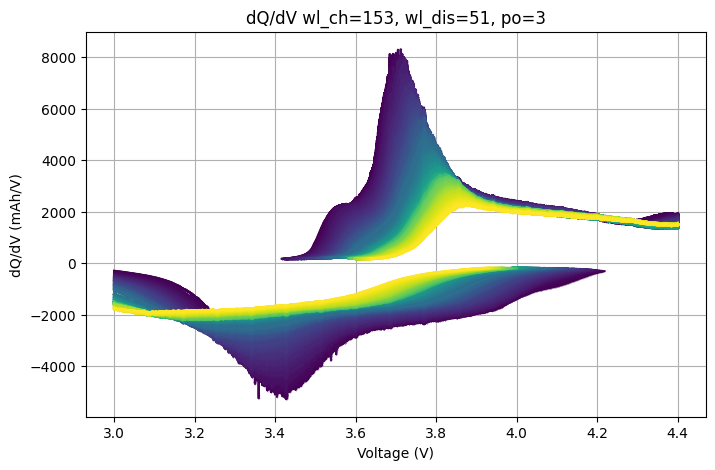

"\ndiccio = {21: {'Ch': df_ch_21, 'Dis': df_dis_21},\n        99: {'Ch': df_ch_99, 'Dis': df_dis_99},\n        ...: {...}}\n"

In [6]:
# --- Trunco datos y calculo derivada ---

# Para NMC-20:
# charge (wl = 153, truncar los n=30 puntos iniciales)
# discharge (wl = 51 = 153 / 3, truncar los n=10=30/3 puntos finales)
# Esto se debe a que la señal de carga tiene 3 veces mas resolución que la de descarga.
# Estos valores pueden cambiar según el dataset.

diccio = dr.truncar_señal(ciclos_sel, dict_ciclos_sep, n_dis=10, n_ch=30)
diccio =  dr.plot_dqdV(ciclos_sel, diccio)

'''
diccio = {21: {'Ch': df_ch_21, 'Dis': df_dis_21},
        99: {'Ch': df_ch_99, 'Dis': df_dis_99},
        ...: {...}}
'''
# --- Exportar a csv para trabajar en Origin ---
#dict[21]['Ch'].to_csv(output_folder / 'df_ch_21.csv', index=False)
#dict[21]['Dis'].to_csv(output_folder / 'df_dis_21.csv', index=False)

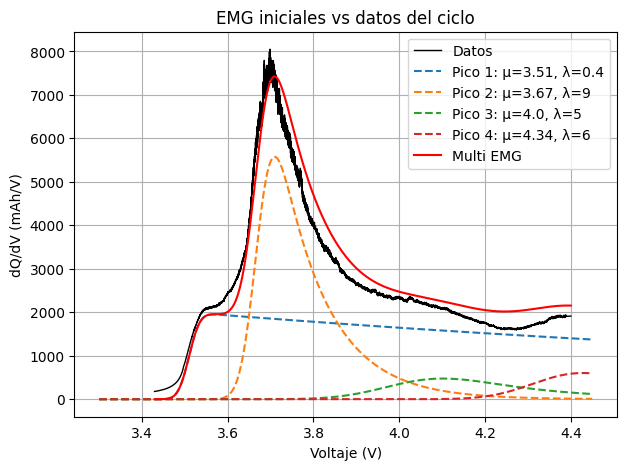

In [7]:
# --- Pruebo manualmente guess inicial para parametros de ajuste ---

# En la EMG los parámetros son: (amplitud, media, sigma, lambda)

df_ch = diccio[21]['Ch']
param_guess = [(5000, 3.51, 0.02, 0.4), 
               (1000, 3.67, 0.03, 9), 
               (200, 4.0, 0.1, 5), 
               (220, 4.34, 0.09, 6)]


ft.plot_emg_guess(df_ch, param_guess)

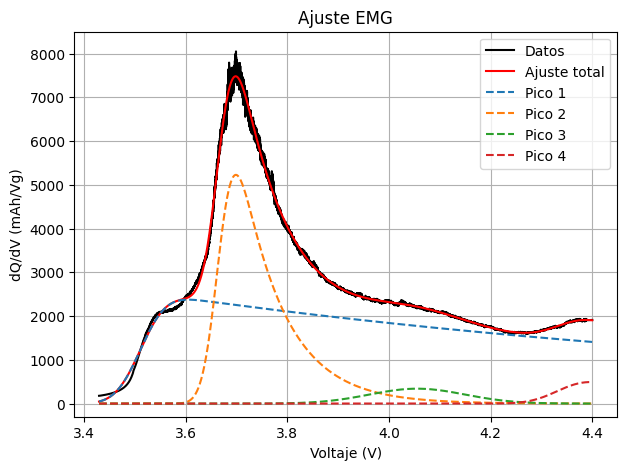

In [8]:
# --- Test de ajuste del primer ciclo ---

# Parámetros iniciales por pico
p_ini_peaks = [
    (5000, 3.51, 0.02, 0.4),
    (1000, 3.67, 0.03, 9),
    (200, 4.0, 0.1, 5),
    (220, 4.34, 0.09, 6)
]

n_peaks = len(p_ini_peaks)

# Construir p_ini_emg y bounds automáticamente
p_ini_emg = []
lb, ub = [], []

for a0, mu0, sigma0, lam0 in p_ini_peaks:
    p_ini_emg += [a0, mu0, sigma0, lam0]
    lb += [0, mu0-0.05, 1e-6, 0]
    ub += [np.inf, mu0+0.05, np.inf, lam0*10]

bounds_emg = (lb, ub)

# Ajuste del ciclo 21 de carga
df_ch_21 = diccio[21]['Ch']
p_opt_21, cov_21 = ft.fit_emg_ciclo(df_ch_21, p_ini_emg, bounds_emg)
ft.plot_emg_fit(df_ch_21, p_opt_21)

In [ ]:
# --- Ajuste de múltiples ciclos ---

# ---- Elegir ciclos del loop y nombre del .csv ------------------------------------------------
#nombre = 'EMG_betterguess2'
#ciclos_sel = ciclos_sel  # ciclos seleccionados previamente
#ciclos_grafico = [21, 99, 198, 297, 396, 498, 597, 696, 795, 897]
# ------------------------------------------------------------------------------------------------

#parametros, covs = ft.fitloop_emg_lamfijo(
#    diccio,
#    ciclos=ciclos_sel,
#    p_ini_emg=p_ini_emg,
#    bounds_emg=bounds_emg,
#    ciclos_grafico=ciclos_grafico
#)

#ft.guardar_parametros_emg(parametros, ciclos_sel, nombre)

In [28]:
# --- Trabajo con parámetros previamente ajustados ---

df_param = pd.read_csv("../output/parametros_ajustes_EMG_betterguess2.csv", index_col=0)
df_param.head()

,a1,mu1,sigma1,lambda1,a2,mu2,sigma2,lambda2,a3,mu3,sigma3,lambda3,a4,mu4,sigma4,lambda4
21,3814.876993,3.511462,0.039376,0.66911,747.967451,3.666574,0.024883,11.536278,80.481535,4.036149,0.092128,50.0,120.287185,4.341188,0.046258,7.141221
24,3799.245854,3.511889,0.035449,0.66911,746.743384,3.664647,0.027371,11.536278,77.633186,4.026146,0.101341,50.0,114.381649,4.335409,0.041632,7.141221
27,3665.158494,3.514373,0.034002,0.66911,782.886055,3.665219,0.024634,11.536278,85.396505,4.030225,0.091207,50.0,124.154853,4.339357,0.045795,7.141221
33,3797.667901,3.516411,0.034489,0.66911,741.804301,3.669148,0.024413,11.536278,84.806683,4.020258,0.095836,50.0,117.839424,4.361507,0.041216,7.141221
36,3731.636547,3.514570,0.031040,0.66911,758.659538,3.669005,0.025663,11.536278,93.287351,4.049256,0.095266,50.0,129.622302,4.359309,0.043571,7.141221


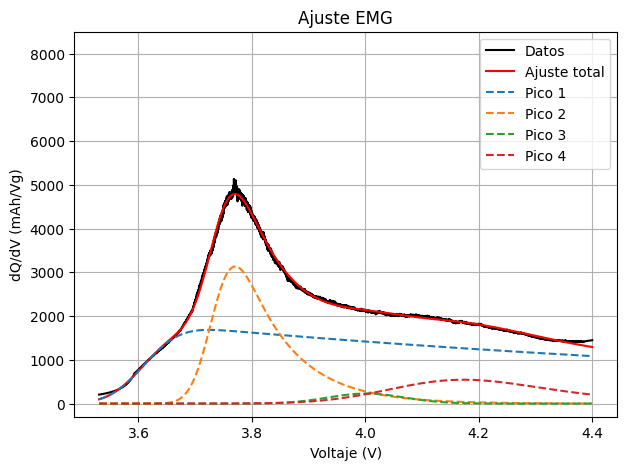

In [10]:
# --- Plot de un ciclo en particular ---

# ------ Elegir cuál y de qué loop ---------------
ciclo = 300
df_param = pd.read_csv("../output/parametros_ajustes_EMG_betterguess2.csv", index_col=0)
nombre = '_EMG_betterguess2' # etiqueta gráfico
# ------------------------------------------------

# Ajuste del ciclo i de carga
df_ch_i = diccio[ciclo]['Ch']
popt_i = df_param.loc[ciclo].values

ft.plot_emg_fit(df_ch_i, popt_i, save_path=f'../output/ajuste_picos_ciclo{ciclo}_{nombre}.png')

In [11]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl

In [28]:

def plot_emg_fit_poster(df_ch, popt, nombre_ciclo=None, ylim=(-300, 8500), save_path=None, legend=True):
    """
    Gráfico para póster científico (~15x10 cm).
    Estilo: tipografía grande, líneas más gruesas, picos sólidos y suma punteada.
    Sin recuadro (solo ejes x e y visibles).
    """
    # --- Estilo general ---
    mpl.rcParams.update({
        "font.size": 14,
        "axes.labelsize": 18,
        "axes.titlesize": 18,
        "legend.fontsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "axes.linewidth": 1.4,
    })

    V = df_ch['V_ch_savgol'].values
    dqdv = df_ch['dqdv_ch_calc'].values

    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)  # ~15x10 cm

    # --- Datos experimentales ---
    ax.plot(V, dqdv, color='silver', linewidth=1, label="Datos")

    # --- Picos individuales ---
    n_peaks = len(popt) // 4
    colors = ["#1283C5", "#D99C33", "#3AA341", "#E444B7", "#D55E00"]
    for i in range(n_peaks):
        a, mu, sigma, lam = popt[4*i:4*i+4]
        ax.plot(
            V, ft.emg(V, a, mu, sigma, lam),
            color=colors[i],
            linewidth=1.3, alpha=0.9, label=f"Pico {i+1}"
        )

    # --- Ajuste total (punteado) ---
    y_fit = ft.multi_emg(V, *popt)
    ax.plot(V, y_fit, linestyle='--', color='r', linewidth=1, label="Suma total")

    # --- Etiquetas y formato ---
    ax.set_xlabel("Voltaje (V)", labelpad=8)
    ax.set_ylabel("dQ/dV (mAh/Vg)", labelpad=8)
    if nombre_ciclo:
        ax.set_title(f"Ciclo {nombre_ciclo}", pad=10)
    ax.set_ylim(ylim)

    ax.grid(True, alpha=0.25, linewidth=1)
    if legend:
        ax.legend(frameon=False, loc='best', ncol=1)

    # --- Solo ejes X e Y visibles ---
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
    else:
        plt.show()

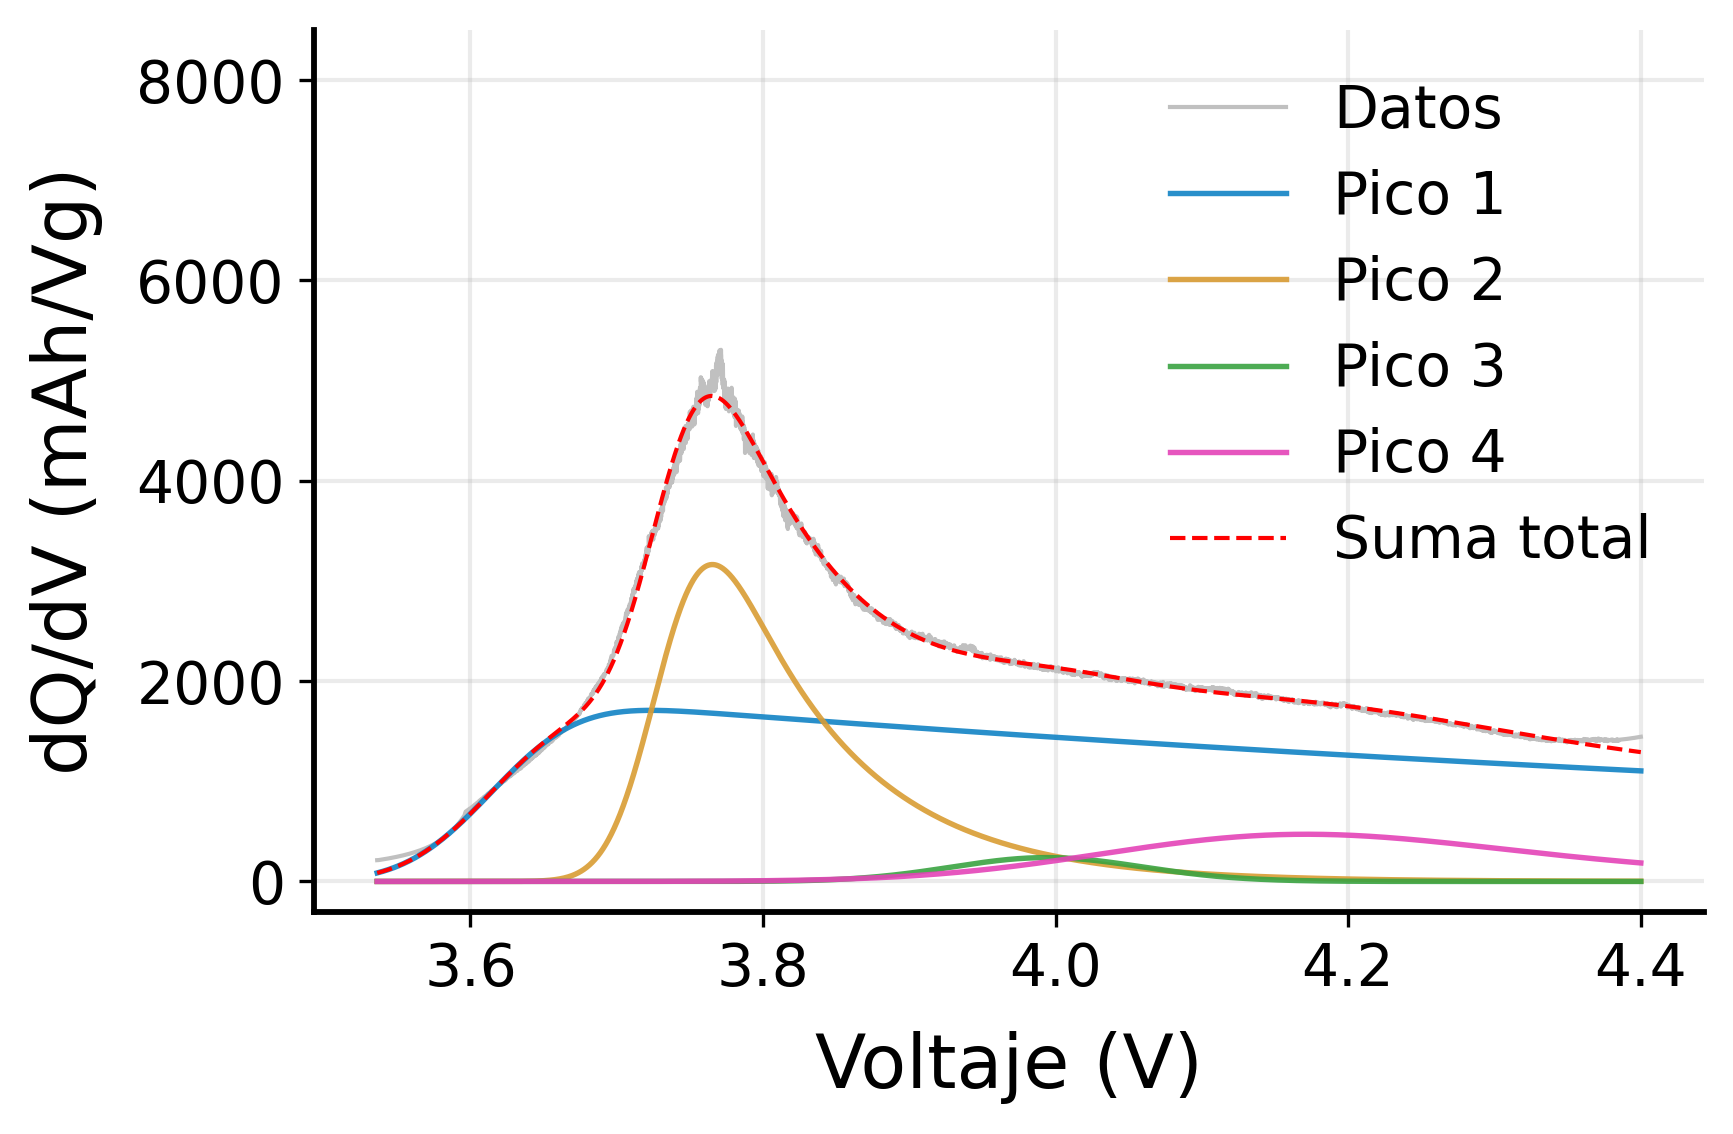

In [62]:
# --- Plot de un ciclo en particular PARA POSTER ---

# ------ Elegir cuál y de qué loop ---------------
ciclo = 303
#df_param = pd.read_csv("../output/parametros_ajustes_EMG_betterguess2.csv", index_col=0)
df_param = pd.read_csv("../output/parametros_ajustes_EMG_poster_300a900-intento2.csv", index_col=0)
nombre = 'POSTER-intento3' # etiqueta gráfico
# ------------------------------------------------

# Ajuste del ciclo i de carga
df_ch_i = diccio[ciclo]['Ch']
popt_i = df_param.loc[ciclo].values

plot_emg_fit_poster(df_ch_i, popt_i, save_path=f'../output/ajuste_picos_ciclo{ciclo}_{nombre}.png')

In [68]:
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import MaxNLocator

def plot_param_evolution(df, param, n_peaks, nombre, exclude_peaks=None):
    """
    Grafica la evolución de un parámetro (a, mu, sigma, lambda) para todos los picos.
    
    df : DataFrame con los parámetros
    param : str, nombre base del parámetro ('a', 'mu', 'sigma', 'lambda')
    n_peaks : int, número de picos
    nombre : str, etiqueta para el archivo de salida
    exclude_peaks : list[int], picos a excluir (opcional, índice base 0)
    """
    exclude_peaks = exclude_peaks or []
    colors = ["#1283C5", "#D99C33", "#3AA341", "#E444B7", "#D55E00"]

    plt.figure()
    for i in range(n_peaks):
        if i not in exclude_peaks:
            plt.plot(df.index, df[f"{param}{i+1}"], 'o-', color=colors[i % len(colors)], label=f"Pico {i+1}")
    plt.xlabel("Ciclo")
    plt.ylabel(param)
    #plt.xticks(df.index[::90])
    # Ticks automáticos para eje x
    
    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(nbins=max_xticks, integer=True))  # máximo max_xticks ticks
    
    plt.title(f"Evolución parámetro {param}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"../output/evolucion_{param}_{nombre}.png", dpi=300)
    plt.show()

In [76]:
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import MaxNLocator

def plot_param_evolution(df, param, n_peaks, nombre, exclude_peaks=None, max_xticks=10):
    exclude_peaks = exclude_peaks or []
    colors = ["#1283C5", "#D99C33", "#3AA341", "#E444B7", "#D55E00"]

    plt.figure()
    for i in range(n_peaks):
        if i not in exclude_peaks:
            plt.plot(df.index, df[f"{param}{i+1}"], 'o-', color=colors[i % len(colors)], label=f"Pico {i+1}", markersize=1)

    plt.xlabel("Ciclo")
    plt.ylabel(param)
    plt.title(f"{param}")
    plt.legend()
    plt.grid(True)

    # Ticks automáticos para eje x
    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(nbins=max_xticks, integer=True))  # máximo max_xticks ticks

    plt.tight_layout()
    plt.savefig(f"../output/evolucion_{param}_{nombre}.png", dpi=300)
    plt.show()

Index([ 21,  24,  27,  33,  36,  39,  42,  45,  48,  51,
       ...
       867, 870, 873, 876, 879, 882, 885, 888, 891, 894],
      dtype='int64', length=488)


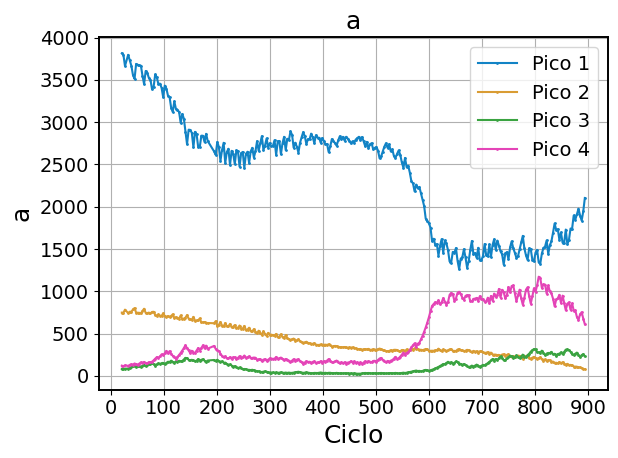

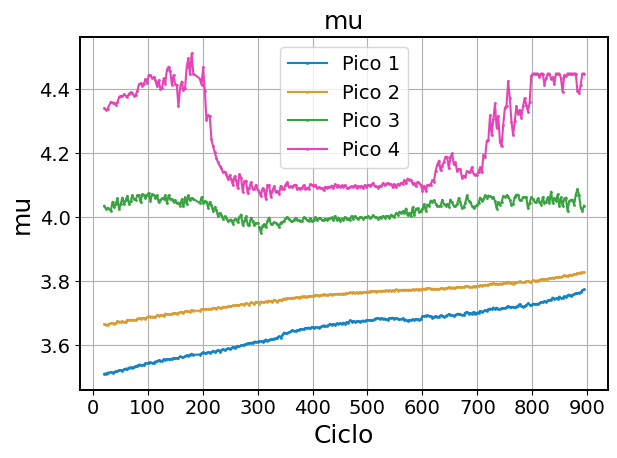

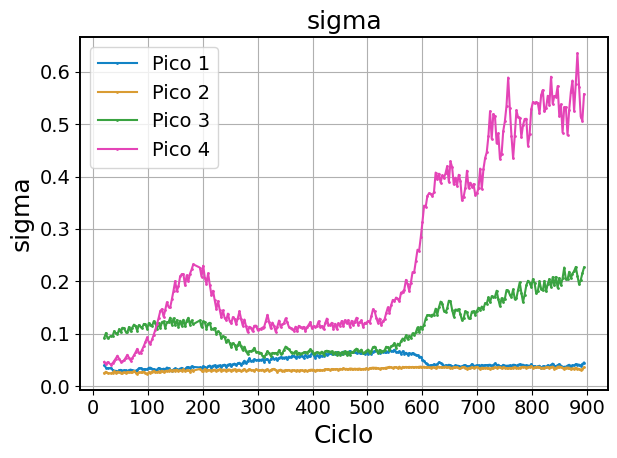

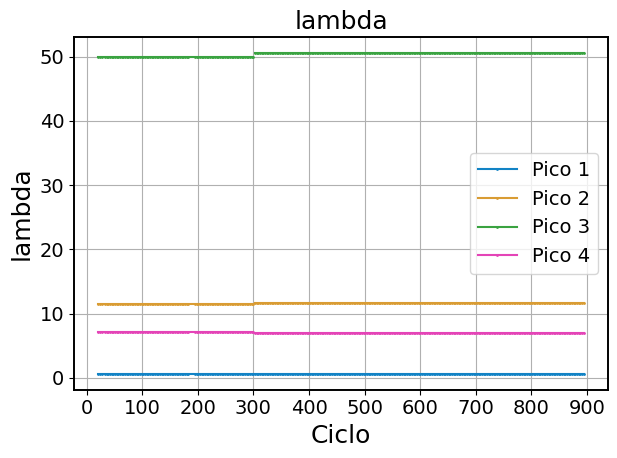

In [77]:
# Leer datos
df_params1 = pd.read_csv("../output/parametros_ajustes_EMG_poster.csv", index_col=0)
df_params2 = pd.read_csv("../output/parametros_ajustes_EMGposter_300a900___________.csv", index_col=0)
df_params = pd.concat([df_params1, df_params2], axis=0)

print(df_params.index)

nombre = 'POSTER-PARAMETROS'
n_peaks = 4

# Graficar todos los parámetros
for p in ['a', 'mu', 'sigma', 'lambda']:
    plot_param_evolution(df_params, p, n_peaks, nombre, exclude_peaks=[])